# スコア別の次の得点までの待ち時間

各チームについて、「次に自分たちが点を取るまでの時間」をその時点のスコアごとに比べる。
途中で相手が点を取ったり試合が終わったりして、次の得点が見られないこともある。そこで、打ち切りを考えた生存時間分析（Kaplan-Meier曲線・ログランク検定）を使う。

### 観測の終わり方
| 終わり方 | 内容 |
|---|---|
| イベント | 自チームが得点した |
| 打ち切り（相手の得点） | 先に相手が得点した（図では赤） |
| 打ち切り（試合終了） | 得点がないまま試合が終わった（図では青） |

### スコアの区分
スコアは「自チームの得点-相手の得点」で表す。

| 区分 | 例 |
|---|---|
| 0-0 | 0-0 |
| 1-0 | 1-0 |
| 0-1 | 0-1 |
| 1-1 | 1-1 |
| 同点(2-2以上) | 2-2, 3-3 |
| 1点差リード(高スコア) | 2-1, 3-2 |
| 1点差ビハインド(高スコア) | 1-2, 2-3 |
| 2点以上リード | 2-0, 3-1 |
| 2点以上ビハインド | 0-2, 1-3 |

## データの作り方

試合をキックオフ・得点・試合終了で区切り、区間ごとにホームとアウェイの観測を1件ずつ作る。

- 区間が得点で終わったら、点を取った側はイベント、もう一方は相手の得点による打ち切り
- 区間が試合終了で終わったら、両方とも試合終了による打ち切り

試合終了の時刻は、各試合に1行ある試合終了の行（`end_time_minutes` が入っている行）から取る。

In [30]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# グラフの日本語が文字化けしないようにする
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False

# 図で使う色
CENSOR_OPPONENT_COLOR = "red"   # 相手の得点による打ち切り
CENSOR_MATCHEND_COLOR = "blue"  # 試合終了による打ち切り
MEDIAN_COLOR = "#009E73"        # 生存時間中央値の線


## 1. データの読み込み

`statsbomb_data` にある全リーグ・全シーズンの `*_goals_and_red_cards.csv` を読み込んで、1つの表にまとめる。

In [31]:
DATA_DIR = "../../statsbomb_data"

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*_goals_and_red_cards.csv"), recursive=True))
print(f"{len(csv_paths)} 件のファイルが見つかりました")

df_all = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
print(f"行数: {len(df_all)}, 試合数: {df_all['match_id'].nunique()}")


11 件のファイルが見つかりました
行数: 10048, 試合数: 2461


## 2. 生存時間データを作る

スコアを9区分に分ける関数と、試合ごとに観測を作る関数を書く。

In [32]:
def categorize_own_perspective(own, opp):
    """自チームの得点 own と相手の得点 opp から、9区分のどれかを返す"""
    diff = own - opp
    if own == 0 and opp == 0:
        return "0-0"
    if own == 1 and opp == 0:
        return "1-0"
    if own == 0 and opp == 1:
        return "0-1"
    if own == 1 and opp == 1:
        return "1-1"
    if diff == 0:  # own == opp >= 2
        return "同点(2-2以上)"
    if diff == 1:  # own >= 2, opp >= 1
        return "1点差リード(高スコア)"
    if diff == -1:  # opp >= 2, own >= 1
        return "1点差ビハインド(高スコア)"
    if diff >= 2:
        return "2点以上リード"
    if diff <= -2:
        return "2点以上ビハインド"
    raise ValueError(f"分類できないスコア: own={own}, opp={opp}")  # ここには来ないはず


CATEGORY_ORDER = [
    "0-0", "1-0", "0-1", "1-1", "同点(2-2以上)",
    "1点差リード(高スコア)", "1点差ビハインド(高スコア)",
    "2点以上リード", "2点以上ビハインド",
]


def build_survival_events(df):
    """試合ごとに、キックオフ・得点・試合終了で区切った区間を作り、
    区間ごとにホームとアウェイの観測を1件ずつ作る
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)
    group_cols = ["league_code", "season_name", "match_id"]
    goal_groups = {key: g.sort_values("time_min") for key, g in goal_rows.groupby(group_cols)}

    # 試合終了の行（1試合に1行）
    end_rows = df[df["red_card"].isna() & df["home_away"].isna() & df["end_time_minutes"].notna()].copy()
    end_rows["full_time_min"] = end_rows["end_time_minutes"].astype(float) + end_rows["end_time_second"].astype(float) / 60.0

    records = []
    for row in end_rows.itertuples(index=False):
        key = (row.league_code, row.season_name, row.match_id)
        full_time = row.full_time_min
        g = goal_groups.get(key)
        if g is None:
            times = np.array([])
            sides = np.array([], dtype=int)
        else:
            times = g["time_min"].to_numpy()
            sides = g["home_away"].to_numpy()  # 0=home, 1=away

        home_score = away_score = 0
        prev_t = 0.0
        meta = dict(league_code=row.league_code, season_name=row.season_name, match_id=row.match_id)

        boundaries = list(times) + [full_time]
        for i, t in enumerate(boundaries):
            duration = t - prev_t
            cat_home = categorize_own_perspective(home_score, away_score)
            cat_away = categorize_own_perspective(away_score, home_score)
            is_last = (i == len(times))  # 最後の区間（試合終了で終わる）なら True

            state_meta = {"home_before": home_score, "away_before": away_score}

            if not is_last:
                scorer = int(sides[i])  # 得点した側（0=home, 1=away）
                if scorer == 0:
                    records.append({**meta, **state_meta, "team": "home", "category": cat_home,
                                     "waiting_time": duration, "event": 1, "censor_type": None})
                    records.append({**meta, **state_meta, "team": "away", "category": cat_away,
                                     "waiting_time": duration, "event": 0, "censor_type": "opponent"})
                    home_score += 1
                else:
                    records.append({**meta, **state_meta, "team": "away", "category": cat_away,
                                     "waiting_time": duration, "event": 1, "censor_type": None})
                    records.append({**meta, **state_meta, "team": "home", "category": cat_home,
                                     "waiting_time": duration, "event": 0, "censor_type": "opponent"})
                    away_score += 1
            else:
                records.append({**meta, **state_meta, "team": "home", "category": cat_home,
                                 "waiting_time": duration, "event": 0, "censor_type": "match_end"})
                records.append({**meta, **state_meta, "team": "away", "category": cat_away,
                                 "waiting_time": duration, "event": 0, "censor_type": "match_end"})

            prev_t = t

    return pd.DataFrame(records)


survival_df = build_survival_events(df_all)
n_event = int((survival_df["event"] == 1).sum())
n_cens_opp = int((survival_df["censor_type"] == "opponent").sum())
n_cens_end = int((survival_df["censor_type"] == "match_end").sum())
print(f"観測数: {len(survival_df)}（イベント: {n_event}, 相手の得点による打ち切り: {n_cens_opp}, "
      f"試合終了による打ち切り: {n_cens_end}）")

survival_df.groupby(["category", "event"]).size().unstack(fill_value=0).reindex(CATEGORY_ORDER)


観測数: 18850（イベント: 6964, 相手の得点による打ち切り: 6964, 試合終了による打ち切り: 4922）


event,0,1
category,,
0-0,2618,2304
1-0,1252,1052
0-1,1484,820
1-1,1102,538
同点(2-2以上),389,103
1点差リード(高スコア),700,303
1点差ビハインド(高スコア),757,246
2点以上リード,1510,1081
2点以上ビハインド,2074,517


## 3. ヒストグラムのビンを決める

待ち時間を5分刻みで数える。全部の図で同じビンを使う。

In [33]:
BIN_WIDTH = 5  # 分
max_wait = survival_df["waiting_time"].max()
BIN_EDGES = np.arange(0, np.ceil(max_wait / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
print(f"最大待ち時間: {max_wait:.2f}分 -> ビン境界: 0〜{BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(BIN_EDGES)-1}ビン）")


最大待ち時間: 99.83分 -> ビン境界: 0〜100分（5分刻み、20ビン）


## 4. Kaplan-Meier曲線を当てはめる

`lifelines` の `KaplanMeierFitter` で、区分ごとにKaplan-Meier曲線を求める。
打ち切りがあると普通の中央値は使えないので、生存確率が0.5以下になる最初の時刻を「生存時間中央値」とする。

In [34]:
try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test
except ModuleNotFoundError:
    # lifelines がなければインストールする
    # インストールしたら、カーネルを再起動してから実行し直す
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "lifelines"])
    raise RuntimeError(
        "lifelines をインストールしました。numpy/matplotlib との整合性のため、"
        "カーネルを再起動してから、このセルより上から再実行してください。"
    )

km_fits = {}
km_summary_rows = []

for cat in CATEGORY_ORDER:
    sub = survival_df[survival_df["category"] == cat]
    n = len(sub)
    if n == 0:
        km_fits[cat] = None
        km_summary_rows.append({"区分": cat, "n": 0, "イベント数": 0,
                                 "相手の得点による打ち切り": 0, "試合終了による打ち切り": 0,
                                 "生存時間中央値me(分)": np.nan})
        continue

    n_event = int((sub["event"] == 1).sum())
    n_cens_opp = int((sub["censor_type"] == "opponent").sum())
    n_cens_end = int((sub["censor_type"] == "match_end").sum())

    kmf = KaplanMeierFitter()
    kmf.fit(durations=sub["waiting_time"], event_observed=sub["event"], label=f"{cat} (n={n})")
    km_fits[cat] = kmf

    km_summary_rows.append({"区分": cat, "n": n, "イベント数": n_event,
                             "相手の得点による打ち切り": n_cens_opp, "試合終了による打ち切り": n_cens_end,
                             "生存時間中央値me(分)": kmf.median_survival_time_})

km_summary = pd.DataFrame(km_summary_rows).set_index("区分").reindex(CATEGORY_ORDER)
km_summary


,n,イベント数,相手の得点による打ち切り,試合終了による打ち切り,生存時間中央値me(分)
区分,,,,,
0-0,4922,2304,2304,314,50.683333
1-0,2304,1052,820,432,42.666667
0-1,2304,820,1052,432,51.933333
1-1,1640,538,538,564,47.650000
同点(2-2以上),492,103,103,286,inf
1点差リード(高スコア),1003,303,246,454,37.783333
1点差ビハインド(高スコア),1003,246,303,454,44.616667
2点以上リード,2591,1081,517,993,27.616667
2点以上ビハインド,2591,517,1081,993,52.916667


## 5. 待ち時間のヒストグラム

区分ごとに待ち時間のヒストグラムを描き、生存時間中央値の位置に点線を引く。

保存しました: ./figures/survival_score_difference_histograms.png


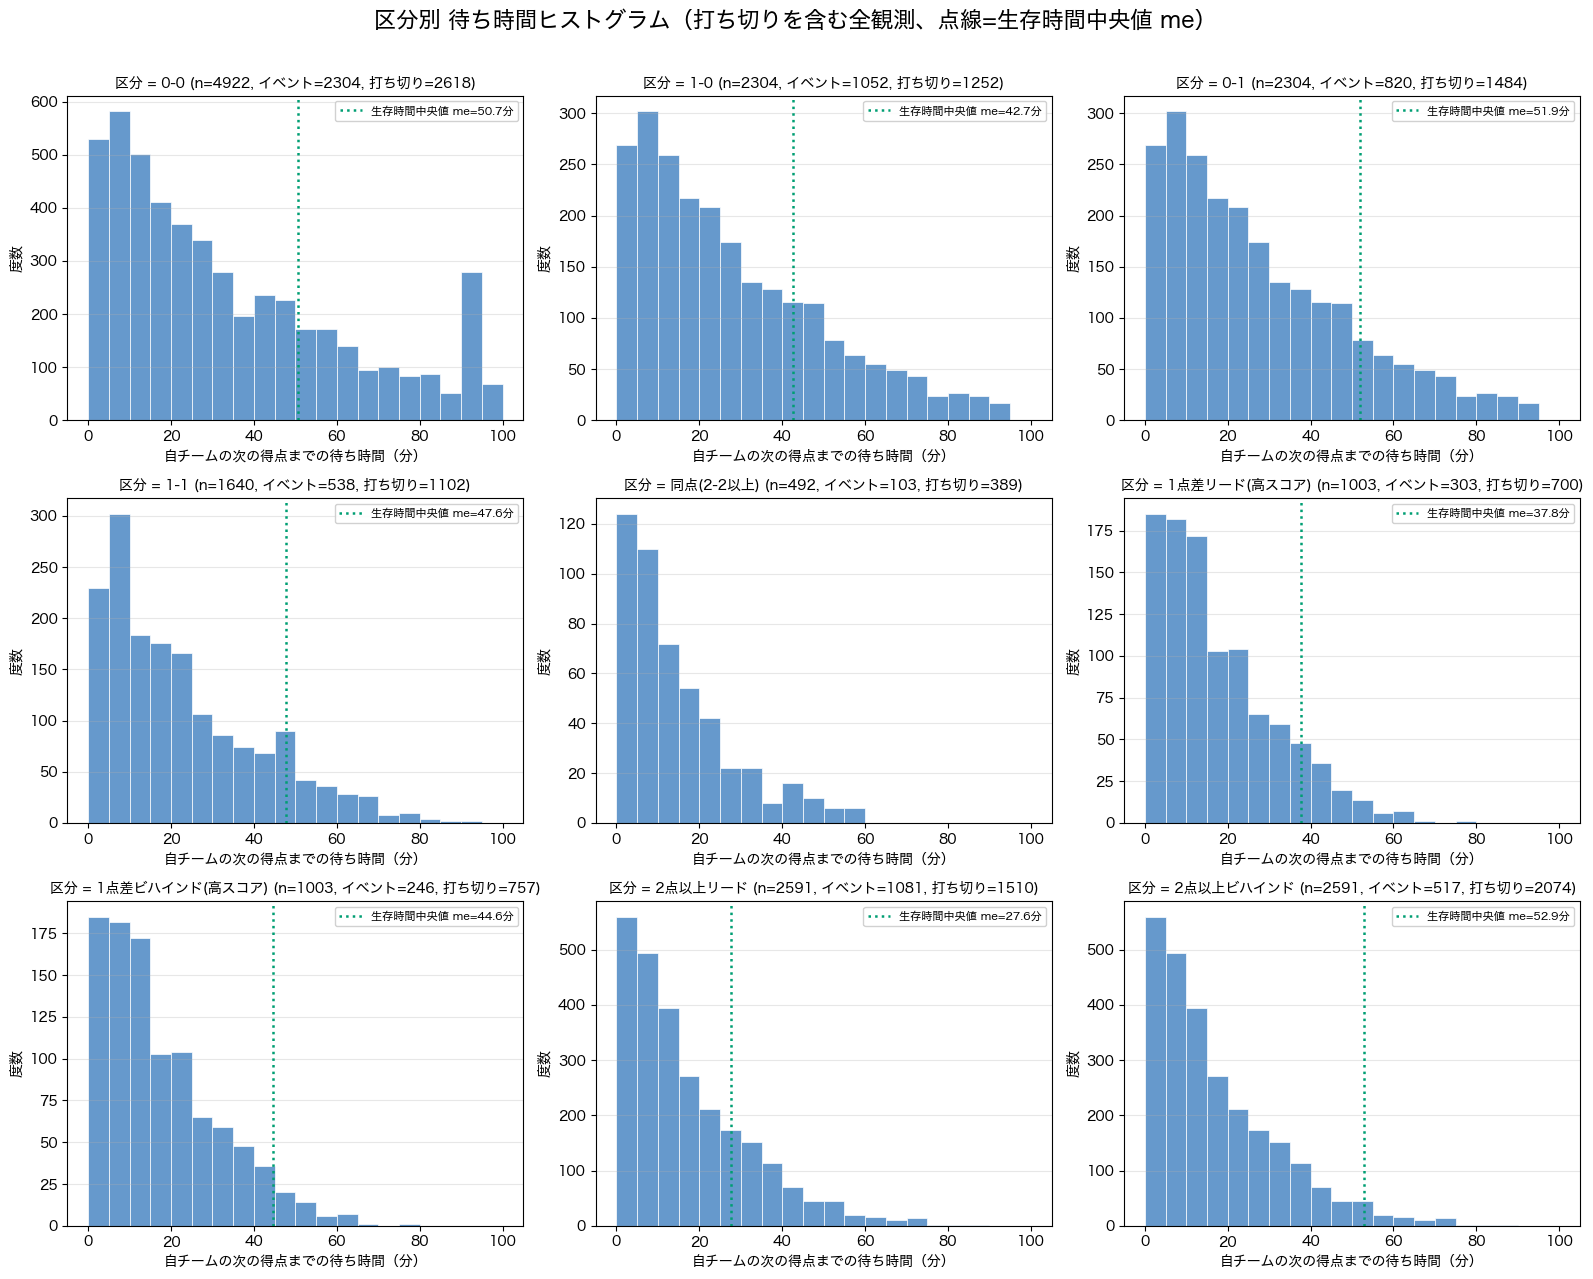

In [35]:
BAR_COLOR = "#6699CC"


def plot_hist_with_km_median(ax, sub_df, kmf, title, bin_edges, label_prefix="区分"):
    vals = sub_df["waiting_time"].values
    n = len(vals)
    n_event = int((sub_df["event"] == 1).sum())
    n_cens = n - n_event

    counts, _ = np.histogram(vals, bins=bin_edges)
    ax.bar(bin_edges[:-1], counts, width=BIN_WIDTH, align="edge",
           color=BAR_COLOR, edgecolor="white", linewidth=0.5)

    if kmf is not None:
        me = kmf.median_survival_time_
        if np.isfinite(me):
            ax.axvline(me, color=MEDIAN_COLOR, linestyle=":", linewidth=1.8,
                        label=f"生存時間中央値 me={me:.1f}分")
            ax.legend(fontsize=8, loc="upper right", framealpha=0.9)

    ax.set_title(f"{label_prefix} = {title} (n={n}, イベント={n_event}, 打ち切り={n_cens})", fontsize=10)
    ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
    ax.set_ylabel("度数")
    ax.grid(axis="y", alpha=0.3)


fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, cat in enumerate(CATEGORY_ORDER):
    sub = survival_df[survival_df["category"] == cat]
    plot_hist_with_km_median(axes[i], sub, km_fits[cat], cat, BIN_EDGES)

for j in range(len(CATEGORY_ORDER), len(axes)):
    axes[j].axis("off")

fig.suptitle("区分別 待ち時間ヒストグラム（打ち切りを含む全観測、点線=生存時間中央値 me）", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_difference_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 6. 区分ごとのKaplan-Meier曲線

区分ごとに1枚ずつ描く。打ち切りがあった時刻には短い縦線を入れる（赤：相手の得点、青：試合終了）。
生存確率0.5の線と、生存時間中央値も書き込む。

保存しました: ./figures/survival_score_difference_km_curves_grid.png


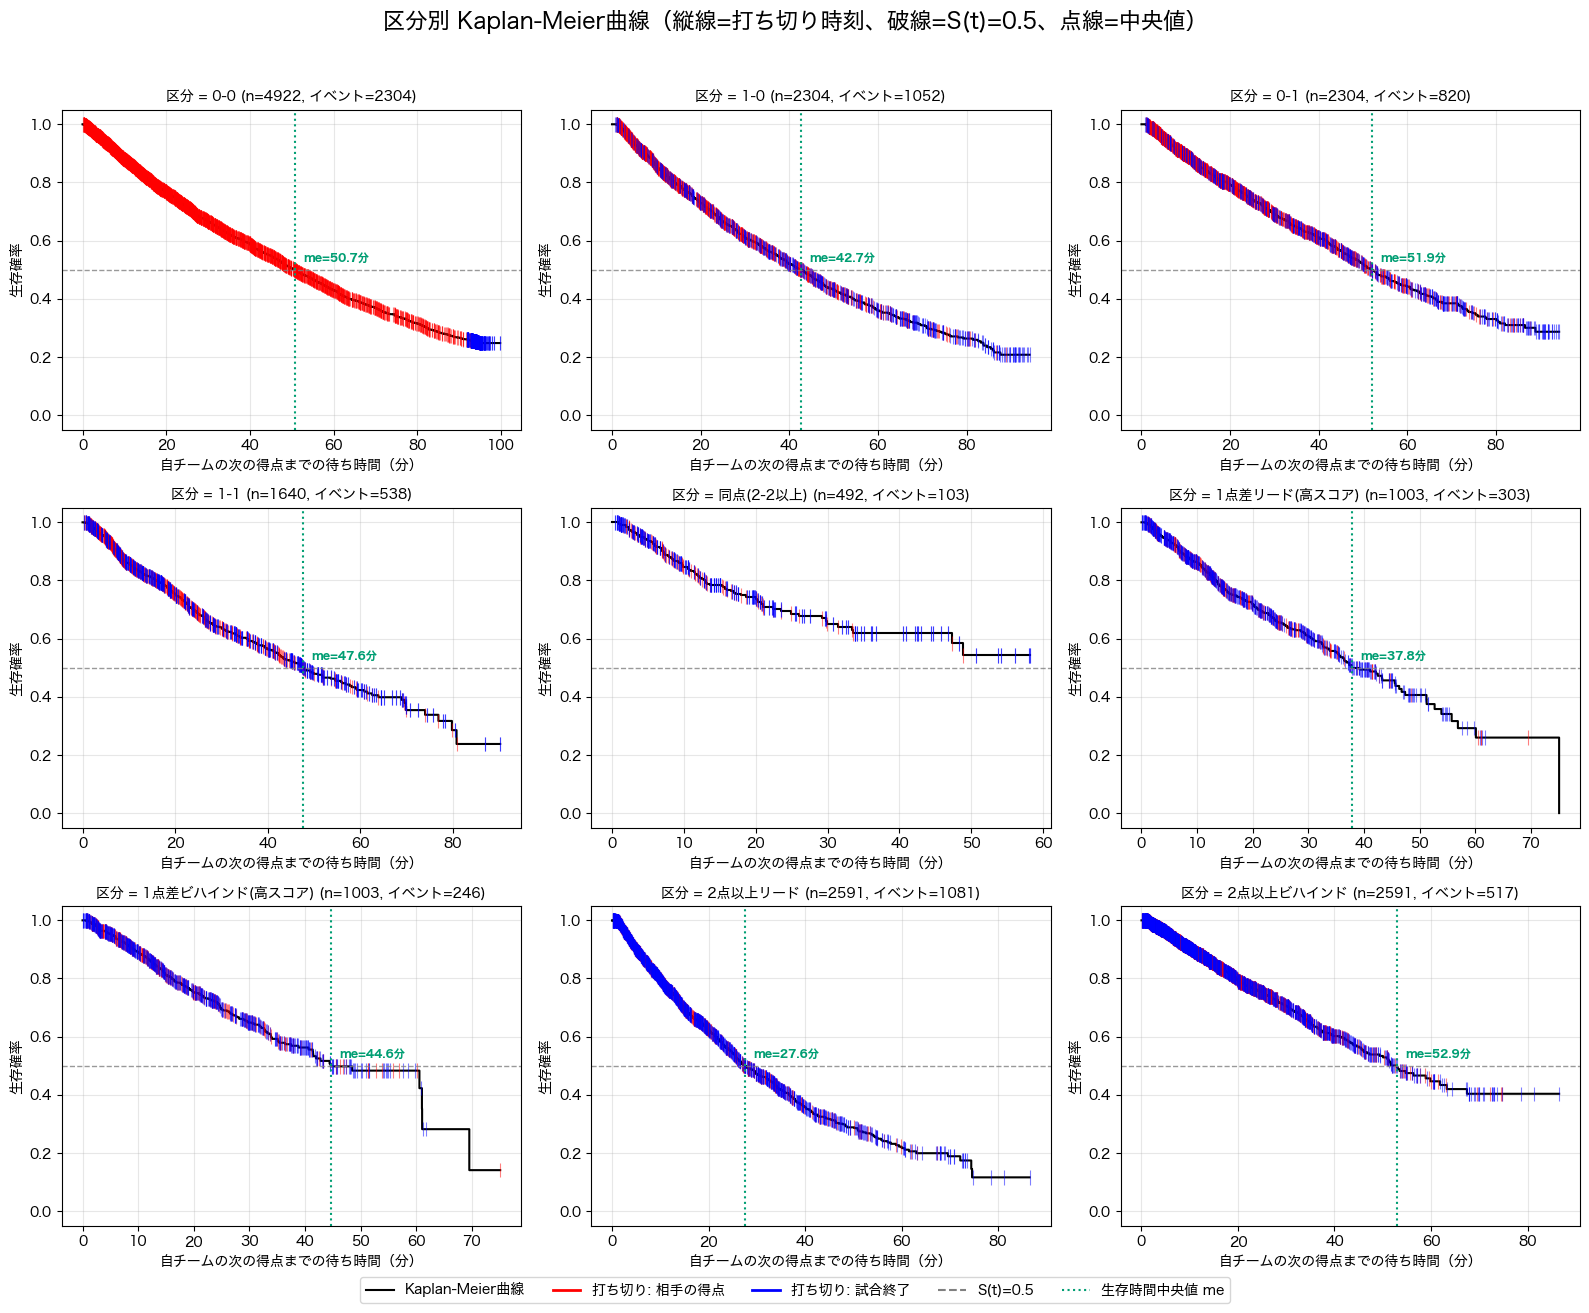

In [36]:
def plot_km_with_censor_marks(ax, sub_df, kmf, title, tick_height=0.025, label_prefix="区分"):
    n = len(sub_df)
    n_event = int((sub_df["event"] == 1).sum())

    kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False, legend=False,
                                color="black", linewidth=1.5)

    for censor_type, color in [("opponent", CENSOR_OPPONENT_COLOR), ("match_end", CENSOR_MATCHEND_COLOR)]:
        t_cens = sub_df.loc[sub_df["censor_type"] == censor_type, "waiting_time"].values
        if len(t_cens) == 0:
            continue
        s_vals = kmf.survival_function_at_times(t_cens).values
        ax.vlines(t_cens, s_vals - tick_height, s_vals + tick_height,
                   color=color, linewidth=0.8, alpha=0.5)

    # S(t)=0.5 の水平線
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)

    # 生存時間中央値の縦線と数字
    me = kmf.median_survival_time_
    if np.isfinite(me):
        ax.axvline(me, color=MEDIAN_COLOR, linestyle=":", linewidth=1.5)
        ax.annotate(f"me={me:.1f}分", xy=(me, 0.5), xytext=(6, 6),
                    textcoords="offset points", fontsize=8, color=MEDIAN_COLOR,
                    fontweight="bold")

    ax.set_title(f"{label_prefix} = {title} (n={n}, イベント={n_event})", fontsize=10)
    ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
    ax.set_ylabel("生存確率")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, cat in enumerate(CATEGORY_ORDER):
    kmf = km_fits[cat]
    if kmf is None:
        axes[i].axis("off")
        continue
    sub = survival_df[survival_df["category"] == cat]
    plot_km_with_censor_marks(axes[i], sub, kmf, cat)

for j in range(len(CATEGORY_ORDER), len(axes)):
    axes[j].axis("off")

legend_handles = [
    Line2D([], [], color="black", linewidth=1.5, label="Kaplan-Meier曲線"),
    Line2D([], [], color=CENSOR_OPPONENT_COLOR, linewidth=2, label="打ち切り: 相手の得点"),
    Line2D([], [], color=CENSOR_MATCHEND_COLOR, linewidth=2, label="打ち切り: 試合終了"),
    Line2D([], [], color="gray", linewidth=1.5, linestyle="--", label="S(t)=0.5"),
    Line2D([], [], color=MEDIAN_COLOR, linewidth=1.5, linestyle=":", label="生存時間中央値 me"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("区分別 Kaplan-Meier曲線（縦線=打ち切り時刻、破線=S(t)=0.5、点線=中央値）", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_difference_km_curves_grid.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"保存しました: {out_path}")
plt.show()


## 7. 9区分を重ねたKaplan-Meier曲線

9区分の曲線を1枚に重ねて比べる。

保存しました: ./figures/survival_score_difference_km_curves_overlay.png


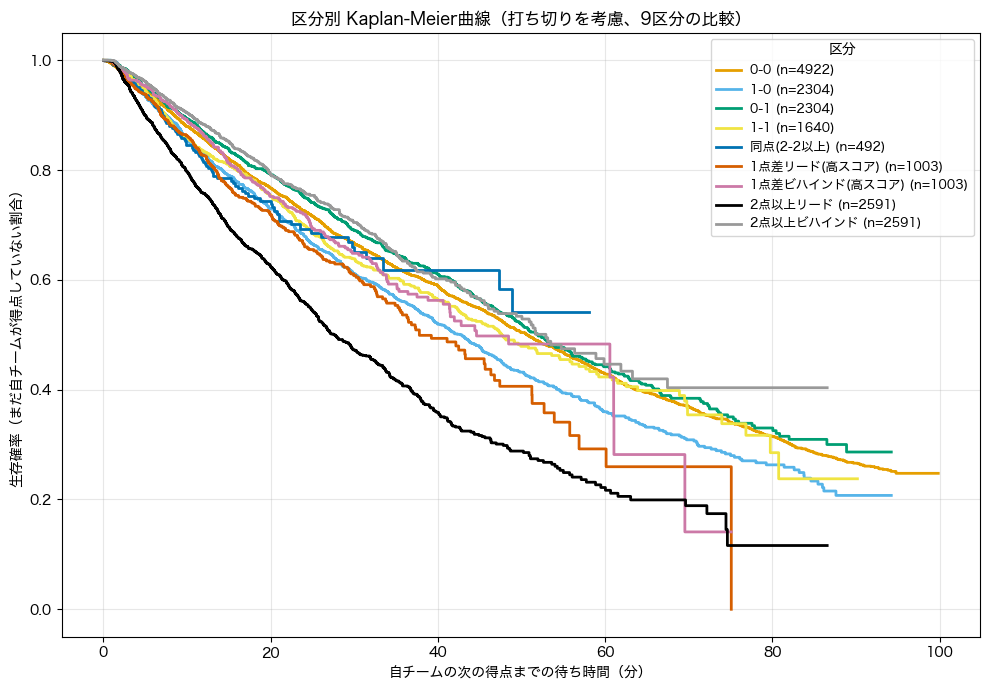

In [37]:
# 区分ごとの色
CATEGORY_COLORS = {
    "0-0": "#E69F00",
    "1-0": "#56B4E9",
    "0-1": "#009E73",
    "1-1": "#F0E442",
    "同点(2-2以上)": "#0072B2",
    "1点差リード(高スコア)": "#D55E00",
    "1点差ビハインド(高スコア)": "#CC79A7",
    "2点以上リード": "#000000",
    "2点以上ビハインド": "#999999",
}

fig, ax = plt.subplots(figsize=(10, 7))

for cat in CATEGORY_ORDER:
    kmf = km_fits[cat]
    if kmf is None:
        continue
    kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False,
                                color=CATEGORY_COLORS[cat], linewidth=2)

ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
ax.set_ylabel("生存確率（まだ自チームが得点していない割合）")
ax.set_title("区分別 Kaplan-Meier曲線（打ち切りを考慮、9区分の比較）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right", title="区分")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_difference_km_curves_overlay.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 8. ログランク検定

9区分をまとめて比べる検定と、2区分ずつ比べる検定（36通り）をする。
2区分ずつの比較は回数が多いので、Bonferroni補正したp値も出しておく。

In [38]:
# 9区分をまとめて比べる
overall_result = multivariate_logrank_test(
    event_durations=survival_df["waiting_time"],
    groups=survival_df["category"],
    event_observed=survival_df["event"],
)
print("=== 9区分一括のログランク検定（打ち切りを考慮） ===")
overall_result.print_summary()

# 2区分ずつ比べる（36通り）
pairwise_result = pairwise_logrank_test(
    event_durations=survival_df["waiting_time"],
    groups=survival_df["category"],
    event_observed=survival_df["event"],
)

pairwise_summary = pairwise_result.summary.copy()
n_comparisons = len(pairwise_summary)
pairwise_summary["p_bonferroni"] = (pairwise_summary["p"] * n_comparisons).clip(upper=1.0)
pairwise_summary = pairwise_summary.sort_values("p")

def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

# p値に星を付ける（例: 2.352009e-26***）
pairwise_summary["p"] = pairwise_summary["p"].apply(lambda v: f"{v:.6e}{stars(v)}")
pairwise_summary["p_bonferroni"] = pairwise_summary["p_bonferroni"].apply(lambda v: f"{v:.6e}{stars(v)}")

print(f"\n=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数={n_comparisons}） ===")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")
pairwise_summary


=== 9区分一括のログランク検定（打ち切りを考慮） ===



=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数=36） ===
有意水準: * p<0.10, ** p<0.05, *** p<0.01


,,test_statistic,p,-log2(p),p_bonferroni
0-0,2点以上リード,246.968762,1.189303e-55***,182.455928,4.281492e-54***
0-1,2点以上リード,210.572609,1.030243e-47***,156.087636,3.708874e-46***
2点以上ビハインド,2点以上リード,199.085497,3.306733e-45***,147.761358,1.190424e-43***
1-1,2点以上リード,99.238671,2.238333e-23***,75.241921,8.058000e-22***
1-0,2点以上リード,89.727277,2.733600e-21***,68.309688,9.840959e-20***
1点差ビハインド(高スコア),2点以上リード,63.127620,1.937383e-15***,48.874812,6.974579e-14***
1-0,2点以上ビハインド,31.769318,1.736138e-08***,25.779543,6.250096e-07***
1点差リード(高スコア),2点以上ビハインド,30.048469,4.213812e-08***,24.500299,1.516972e-06***
0-1,1-0,28.755046,8.213563e-08***,23.537417,2.956883e-06***
1点差リード(高スコア),2点以上リード,28.627485,8.772811e-08***,23.442386,3.158212e-06***
